In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns

In [2]:
if not os.path.exists('data/caravan-insurance-challenge.csv'):
    !git clone https://github.com/vanraak/intro-ml.git
    %cd intro-ml

In [3]:
df = pd.read_csv("data/caravan-insurance-challenge.csv")

In [4]:
# We will generate a test set ourselves
df = df.drop(columns="ORIGIN")

Data dictionary:

https://kdd.ics.uci.edu/databases/tic/dictionary.txt

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9822 entries, 0 to 9821
Data columns (total 86 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   MOSTYPE   9822 non-null   int64
 1   MAANTHUI  9822 non-null   int64
 2   MGEMOMV   9822 non-null   int64
 3   MGEMLEEF  9822 non-null   int64
 4   MOSHOOFD  9822 non-null   int64
 5   MGODRK    9822 non-null   int64
 6   MGODPR    9822 non-null   int64
 7   MGODOV    9822 non-null   int64
 8   MGODGE    9822 non-null   int64
 9   MRELGE    9822 non-null   int64
 10  MRELSA    9822 non-null   int64
 11  MRELOV    9822 non-null   int64
 12  MFALLEEN  9822 non-null   int64
 13  MFGEKIND  9822 non-null   int64
 14  MFWEKIND  9822 non-null   int64
 15  MOPLHOOG  9822 non-null   int64
 16  MOPLMIDD  9822 non-null   int64
 17  MOPLLAAG  9822 non-null   int64
 18  MBERHOOG  9822 non-null   int64
 19  MBERZELF  9822 non-null   int64
 20  MBERBOER  9822 non-null   int64
 21  MBERMIDD  9822 non-null   int64
 22  MBERARBG  9

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MOSTYPE,9822.0,24.253207,12.918058,1.0,10.0,30.0,35.0,41.0
MAANTHUI,9822.0,1.108735,0.412101,1.0,1.0,1.0,1.0,10.0
MGEMOMV,9822.0,2.677561,0.780701,1.0,2.0,3.0,3.0,6.0
MGEMLEEF,9822.0,2.996437,0.804660,1.0,2.0,3.0,3.0,6.0
MOSHOOFD,9822.0,5.779067,2.874148,1.0,3.0,7.0,8.0,10.0
...,...,...,...,...,...,...,...,...
APLEZIER,9822.0,0.005091,0.077996,0.0,0.0,0.0,0.0,2.0
AFIETS,9822.0,0.031460,0.209070,0.0,0.0,0.0,0.0,4.0
AINBOED,9822.0,0.008450,0.092647,0.0,0.0,0.0,0.0,2.0
ABYSTAND,9822.0,0.013846,0.117728,0.0,0.0,0.0,0.0,2.0


In [7]:
df['CARAVAN'].value_counts()

CARAVAN
0    9236
1     586
Name: count, dtype: int64

<Axes: xlabel='CARAVAN', ylabel='count'>

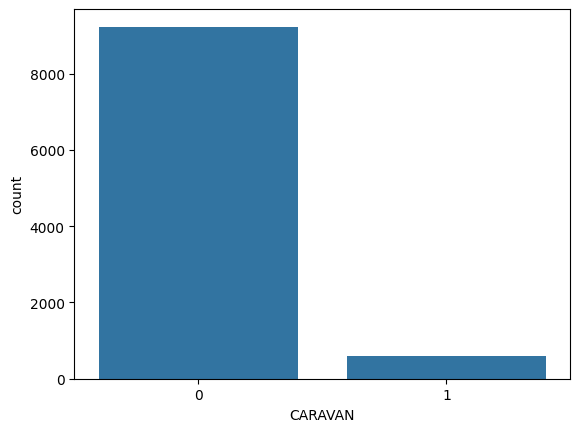

In [8]:
sns.countplot(df, x="CARAVAN")

In [9]:
df.head()

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,CARAVAN
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,0
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,0
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,0
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,0
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,0


<Axes: >

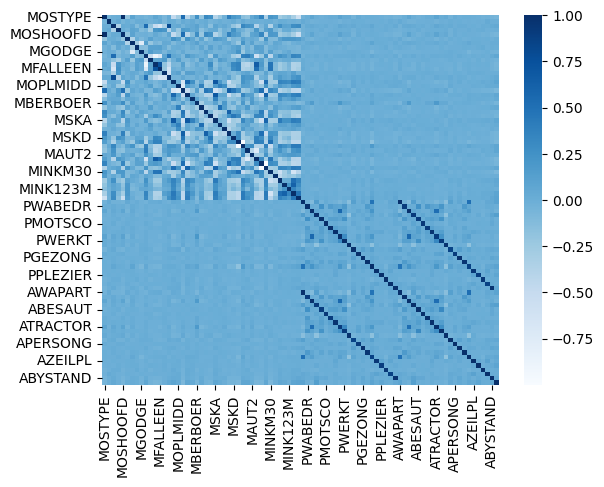

In [10]:
sns.heatmap(df.corr(), cmap="Blues")

We notice very high correlations. This is caused by variables such as `PWAPART (Contribution private third party insurance)` and the related indicator of the number of policies `AWAPART Number of private third party insuranc`.

Examine `CARAVAN` per customer type:

<Axes: xlabel='MOSTYPE', ylabel='Count'>

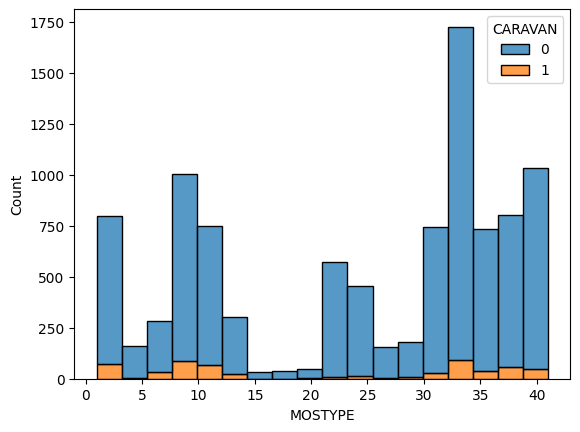

In [11]:
sns.histplot(df, x="MOSTYPE", hue="CARAVAN", multiple="stack")

<Axes: xlabel='MOSTYPE', ylabel='Count'>

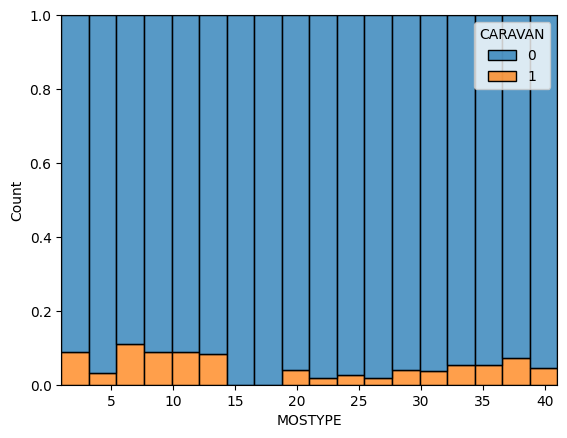

In [12]:
sns.histplot(df, x="MOSTYPE", hue="CARAVAN", multiple="fill")

Average age:

<Axes: xlabel='MGEMLEEF', ylabel='Count'>

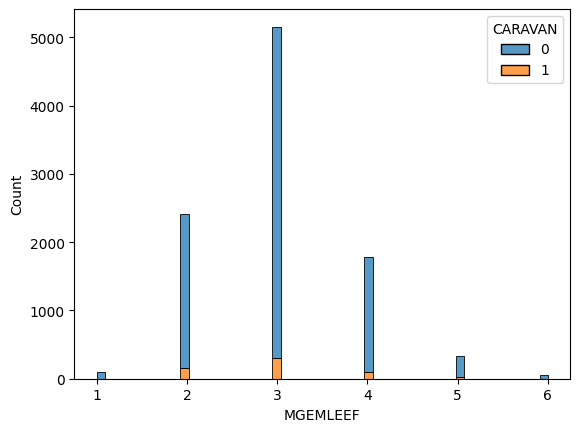

In [13]:
sns.histplot(df, x="MGEMLEEF", hue="CARAVAN", multiple="stack")

<Axes: xlabel='MGEMLEEF', ylabel='Count'>

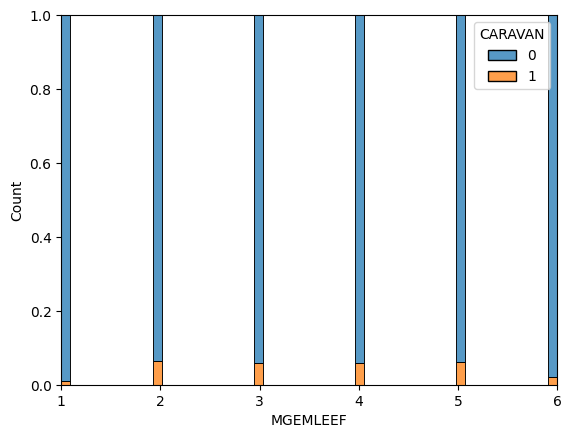

In [14]:
sns.histplot(df, x="MGEMLEEF", hue="CARAVAN", multiple="fill")

Purchasing power class

<Axes: xlabel='MKOOPKLA', ylabel='Count'>

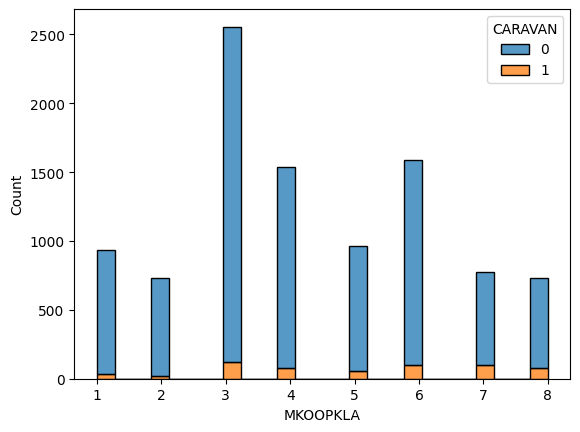

In [15]:
sns.histplot(df, x="MKOOPKLA", hue="CARAVAN", multiple="stack")

<Axes: xlabel='MKOOPKLA', ylabel='Count'>

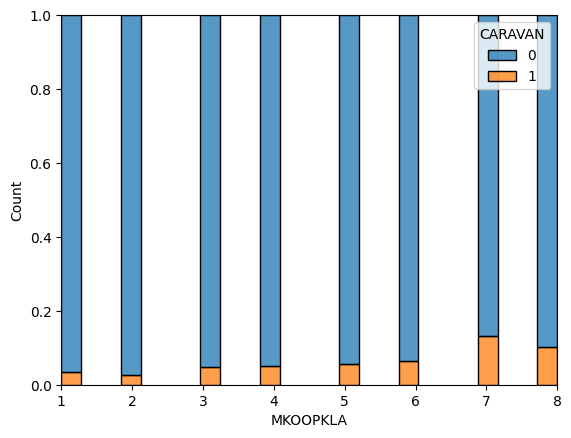

In [16]:
sns.histplot(df, x="MKOOPKLA", hue="CARAVAN", multiple="fill")

Earllier we noticed some overlap between features. For this reason, we select a subset of the features.

In [17]:
selected_features = [
    # Customer type
    'MOSTYPE',

    # Demographics
    'MAANTHUI', 'MGEMOMV', 'MGEMLEEF',
    'MRELGE', 'MRELSA', 'MRELOV',
    'MFALLEEN', 'MFGEKIND', 'MFWEKIND',

    # Housing & assets
    'MHHUUR', 'MHKOOP',
    'MAUT0', 'MAUT1', 'MAUT2',

    # Education
    'MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG',

    # Social class / occupation
    'MBERHOOG', 'MBERMIDD', 'MBERARBG', 'MBERARBO',
    'MSKA', 'MSKB1', 'MSKB2', 'MSKC', 'MSKD',

    # Income
    'MKOOPKLA',

    # Health insurance
    'MZFONDS', 'MZPART',

    # Selected insurance behavior
    'APERSAUT', 'ABRAND', 'ALEVEN'
]

In [18]:
X = df[selected_features]
y = df["CARAVAN"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

mlp = MLPClassifier(max_iter=1000, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", mlp)
])

In [21]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


In [22]:
y_pred = pipeline.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy:  0.9176
Recall:    0.0598
Precision: 0.1186


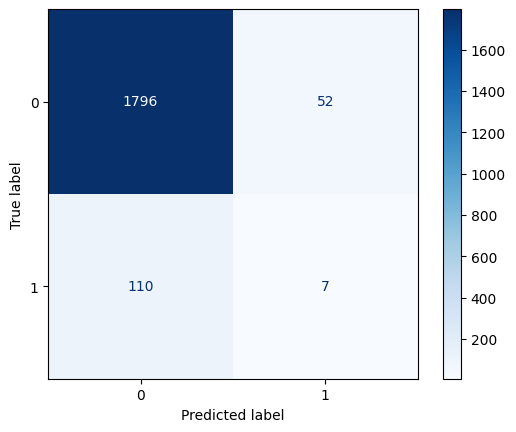

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

# Threshold tuning

In [25]:
y_proba = pipeline.predict_proba(X_test)

In [26]:
y_proba[0:10]

array([[9.76678205e-01, 2.33217951e-02],
       [9.90985087e-01, 9.01491311e-03],
       [7.30462742e-01, 2.69537258e-01],
       [9.99915844e-01, 8.41555324e-05],
       [9.80365155e-01, 1.96348448e-02],
       [9.99991774e-01, 8.22587644e-06],
       [9.60767698e-01, 3.92323022e-02],
       [9.99997774e-01, 2.22630371e-06],
       [9.99996663e-01, 3.33691695e-06],
       [7.34454355e-01, 2.65545645e-01]])

The F1-score measures the balance between precision and recall, giving a high score only when both are high.

$$
F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

We can find the threshold that maximizes the F1-Score.

In [27]:
from sklearn.model_selection import TunedThresholdClassifierCV

model = TunedThresholdClassifierCV(
    pipeline,
    scoring="f1"
)

model.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,copy,True
,with_mean,True


In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy:  0.7196
Recall:    0.4615
Precision: 0.0996


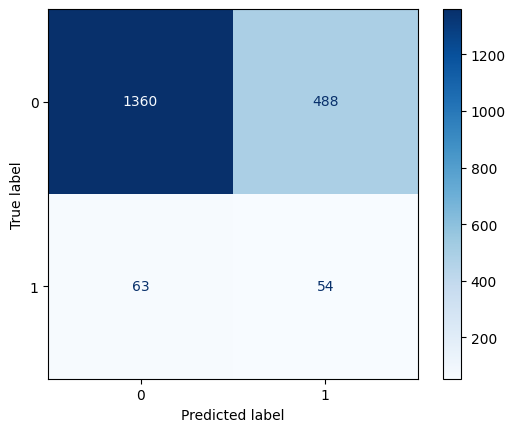

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

In [38]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [41]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"""
Interpretation:

FN (False Negatives) = {fn}  
→ These are customers who would have bought insurance, but we missed them.  
→ This is wasted opportunity / lost revenue.

FP (False Positives) = {fp}  
→ These are customers we predicted would buy, but they actually won't.  
→ This leads to unnecessary marketing costs.

Why high recall?

We want to minimize FN, because missing a potential customer means losing a sale.  
A high recall ensures we capture as many real buyers as possible.
""")


Interpretation:

FN (False Negatives) = 63  
→ These are customers who would have bought insurance, but we missed them.  
→ This is wasted opportunity / lost revenue.

FP (False Positives) = 488  
→ These are customers we predicted would buy, but they actually won't.  
→ This leads to unnecessary marketing costs.

Why high recall?

We want to minimize FN, because missing a potential customer means losing a sale.  
A high recall ensures we capture as many real buyers as possible.



In [56]:
from IPython.display import Markdown, display

def mprint(text):
    display(Markdown(text))

mprint(f"""
<u>**Interpretation**</u>

FN (False Negatives) = **{fn}**
*→ These are customers who would have bought caravan insurance, but we missed them.*
*→ This is wasted opportunity / lost revenue.*

FP (False Positives) = **{fp}**
*→ These are customers we predicted would buy insurance, but they actually won't.*
*→ This leads to unnecessary marketing costs.*

*Why high recall?*

We want to minimize FN, because missing a potential customer means losing a sale.  
A high recall ensures we capture as many real buyers as possible.
""")


<u>**Interpretation**</u>

FN (False Negatives) = **63**
*→ These are customers who would have bought caravan insurance, but we missed them.*
*→ This is wasted opportunity / lost revenue.*

FP (False Positives) = **488**
*→ These are customers we predicted would buy insurance, but they actually won't.*
*→ This leads to unnecessary marketing costs.*

*Why high recall?*

We want to minimize FN, because missing a potential customer means losing a sale.  
A high recall ensures we capture as many real buyers as possible.
